## Retrieving the `CheMeleon` Model

In [10]:
from urllib.request import urlretrieve

urlretrieve(
    r"https://zenodo.org/records/15460715/files/chemeleon_mp.pt",
    "chemeleon_mp.pt",
)



('chemeleon_mp.pt', <http.client.HTTPMessage at 0x40fd3da90>)

## Initializing `CheMeleon`

In [11]:
import torch

from chemprop import featurizers, nn

featurizer = featurizers.SimpleMoleculeMolGraphFeaturizer()
agg = nn.MeanAggregation()
chemeleon_mp = torch.load("chemeleon_mp.pt", weights_only=True)
mp = nn.BondMessagePassing(**chemeleon_mp['hyper_parameters'])
mp.load_state_dict(chemeleon_mp['state_dict'])

<All keys matched successfully>

# Data loader method from Kerner et. al

In [12]:
import pandas as pd
import numpy as np
from typing import Tuple, List
from sklearn.model_selection import StratifiedKFold


def load_curated_datasets() -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    data_dir = "/Users/viggo/Documents/AI4Mol/Project/GNN_chemprop/data"
    df_curated_biowin = pd.read_csv(f"{data_dir}/class_curated_biowin.csv", index_col=0)
    df_curated_final = pd.read_csv(f"{data_dir}/class_curated_final.csv", index_col=0)
    df_curated_scs = pd.read_csv(f"{data_dir}/class_curated_scs.csv", index_col=0)
    return df_curated_biowin, df_curated_final, df_curated_scs


def split_classification_df_with_fixed_test_set(
    df: pd.DataFrame,
    df_test: pd.DataFrame,
    nsplits: int,
    random_seed: int,
    cols: List[str],
    paper: bool,
) -> Tuple[List[pd.DataFrame], List[pd.DataFrame]]:
    train_sets: List[pd.DataFrame] = []
    test_sets: List[pd.DataFrame] = []

    dfs = [df, df_test]
    for i, d in enumerate(dfs):
        if "inchi_from_smiles" not in d.columns:
            df_smiles_correct = remove_smiles_with_incorrect_format(df=d, col_name_smiles="smiles")
            dfs[i] = openbabel_convert(
                df=df_smiles_correct,
                input_type="smiles",
                column_name_input="smiles",
                output_type="inchi",
            )
    df = dfs[0][cols + ["inchi_from_smiles"]]
    df_test = dfs[1][cols + ["inchi_from_smiles"]]

    skf = StratifiedKFold(n_splits=nsplits, shuffle=True, random_state=random_seed)
    for _, test_index in skf.split(df_test[cols + ["inchi_from_smiles"]], df_test["y_true"]):
        df_test_set = df_test[df_test.index.isin(test_index)]
        train_set = df[~df["inchi_from_smiles"].isin(df_test_set["inchi_from_smiles"])]
        if paper:
            df_checked = pd.read_excel("datasets/chemical_speciation.xlsx", index_col=0)
            test_checked = df_checked[
                df_checked["env_smiles"].isin(df_test_set["smiles"]) |
                df_checked["inchi_from_smiles"].isin(df_test_set["inchi_from_smiles"])
            ]
            train_set = train_set[~(train_set["inchi_from_smiles"].isin(test_checked["inchi_from_smiles"]))]
            train_set = train_set[~(train_set["smiles"].isin(test_checked["env_smiles"]))]
            train_set = train_set.loc[~((train_set["cas"].isin(test_checked["cas"])) & (test_checked["cas"].notna())), :]
            train_set = train_set.loc[~((train_set["cas"].isin(df_test_set["cas"])) & (df_test_set["cas"].notna())), :]
        train_sets.append(train_set)
        test_sets.append(df_test_set)

    return train_sets, test_sets

def skf_class_fixed_testset(
    df: pd.DataFrame,
    df_test: pd.DataFrame,
    nsplits: int,
    random_seed: int,
    include_speciation: bool,
    cols: List[str],
    paper: bool,
    target_col: str,
) -> Tuple[List[np.ndarray], List[np.ndarray], List[np.ndarray], List[np.ndarray], List[pd.DataFrame], List[int]]:
    train_sets, test_sets = split_classification_df_with_fixed_test_set(
        df=df,
        df_test=df_test,
        nsplits=nsplits,
        random_seed=random_seed,
        cols=cols,
        paper=paper,
    )
    x_train_fold_lst: List[np.ndarray] = []
    y_train_fold_lst: List[np.ndarray] = []
    x_test_fold_lst: List[np.ndarray] = []
    y_test_fold_lst: List[np.ndarray] = []
    df_test_lst: List[pd.DataFrame] = []
    test_set_sizes: List[int] = []

    for split in range(nsplits):
        train_fold = train_sets[split]
        test_fold = test_sets[split]
        x_train_fold_lst.append(train_fold["smiles"].values)
        y_train_fold_lst.append(train_fold[target_col].values)
        x_test_fold_lst.append(test_fold["smiles"].values)
        y_test_fold_lst.append(test_fold[target_col].values)
        df_test_lst.append(test_fold.copy())
        test_set_sizes.append(len(test_fold))

    return x_train_fold_lst, y_train_fold_lst, x_test_fold_lst, y_test_fold_lst, df_test_lst, test_set_sizes

df_biowin, df_final, df_scs = load_curated_datasets()

x_train_folds, y_train_folds, x_test_folds, y_test_folds, _, _ = skf_class_fixed_testset(
    df=df_final,
    df_test=df_biowin,  # Change here to use different test set
    nsplits=5,
    random_seed=42,
    include_speciation=False,
    cols=["cas", "smiles", "y_true"],
    paper=False,
    target_col="y_true",
)
print(f"Number of training samples in each fold: {[len(x) for x in x_train_folds]}")
print(x_train_folds[0][:5])
print(y_train_folds[0][:5])
print(x_test_folds[0][:5])
print(y_test_folds[0][:5])

Number of training samples in each fold: [3541, 3541, 3541, 3541, 3542]
<StringArray>
[                                    'CC1=CC(=C(NCCO)C=C1)N(=O)=O',
                                                   'CCCCCC(CO)CCC',
 'CC(C)(C1=CC=CC=C1)C1=CC=C(NC2=CC=C(C=C2)C(C)(C)C2=CC=CC=C2)C=C1',
                                             'C/C(C=O)=C/c1ccccc1',
                                   'NC1=CC=C(CC2=CC=C(N)C=C2)C=C1']
Length: 5, dtype: str
[0 1 0 1 0]
<StringArray>
[           'OCC1=CC=CC=C1',           'C=CC1=CC=CC=N1',
      'COC(=O)CC1=CC=CC=C1',   'ClC1=CC=C(C=C1Cl)N=C=O',
 'CC1=CC(CC(C)(C)CO)=CC=C1']
Length: 5, dtype: str
[1 0 1 0 0]


## Standard Chemprop Preparation

In [13]:
from pathlib import Path

from lightning import pytorch as pl
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping

from chemprop.nn.metrics import BinaryAccuracy, BinaryAUROC

from chemprop import data, models

num_workers = 0 # number of workers for dataloader. 0 means using main process for data loading
smis = x_train_folds[0] #list of smiles strings
ys = y_train_folds[0] #list of target values
#train_data = [data.MoleculeDatapoint.from_smi(smi, y) for smi, y in zip(smis, ys)]

smis_test = x_test_folds[0]
ys_test = y_test_folds[0]
#test_data = [data.MoleculeDatapoint.from_smi(smi, y) for smi, y in zip(smis_test, ys_test)]
#add another for validation set
train_data = [data.MoleculeDatapoint.from_smi(smi, [y]) for smi, y in zip(smis, ys)]
test_data = [data.MoleculeDatapoint.from_smi(smi, [y]) for smi, y in zip(smis_test, ys_test)]

train_dset = data.MoleculeDataset(train_data, featurizer)
#val_dset = data.MoleculeDataset(val_data[0], featurizer)
test_dset = data.MoleculeDataset(test_data, featurizer)
train_loader = data.build_dataloader(train_dset, num_workers=num_workers)
#val_loader = data.build_dataloader(val_dset, num_workers=num_workers, shuffle=False)
test_loader = data.build_dataloader(test_dset, num_workers=num_workers, shuffle=False)
ffn = nn.BinaryClassificationFFN(input_dim=mp.output_dim, dropout=0.2)
metric_list = [BinaryAccuracy(), BinaryAUROC()]
mpnn = models.MPNN(mp, agg, ffn, batch_norm=False, metrics=metric_list)

In [14]:
mpnn #show model architecture

MPNN(
  (message_passing): BondMessagePassing(
    (W_i): Linear(in_features=86, out_features=2048, bias=False)
    (W_h): Linear(in_features=2048, out_features=2048, bias=False)
    (W_o): Linear(in_features=2120, out_features=2048, bias=True)
    (dropout): Dropout(p=0.0, inplace=False)
    (tau): ReLU()
    (V_d_transform): Identity()
    (graph_transform): Identity()
  )
  (agg): MeanAggregation()
  (bn): Identity()
  (predictor): BinaryClassificationFFN(
    (ffn): MLP(
      (0): Sequential(
        (0): Linear(in_features=2048, out_features=300, bias=True)
      )
      (1): Sequential(
        (0): ReLU()
        (1): Dropout(p=0.2, inplace=False)
        (2): Linear(in_features=300, out_features=1, bias=True)
      )
    )
    (criterion): BCELoss(task_weights=[[1.0]])
    (output_transform): Identity()
  )
  (X_d_transform): Identity()
  (metrics): ModuleList(
    (0): BinaryAccuracy()
    (1): BinaryAUROC()
    (2): BCELoss(task_weights=[[1.0]])
  )
)

## Training

In [15]:
import matplotlib.pyplot as plt
from lightning.pytorch.loggers import CSVLogger

# Configure model checkpointing
checkpointing = ModelCheckpoint(
    "checkpoints",  # Directory where model checkpoints will be saved
    "best-{epoch}-{val_loss:.2f}",  # Filename format for checkpoints, including epoch and validation loss
    "val_loss",  # Metric used to select the best checkpoint (based on validation loss)
    mode="min",  # Save the checkpoint with the lowest validation loss (minimization objective)
    save_last=True,  # Always save the most recent checkpoint, even if it's not the best
)
# Add logger to trainer
logger = CSVLogger("logs", name="my_model")
early_stop = EarlyStopping(monitor="val_loss", patience=10, mode="min")
trainer = pl.Trainer(
    logger=logger,
    enable_checkpointing=True, # Use `True` if you want to save model checkpoints. The checkpoints will be saved in the `checkpoints` folder.
    enable_progress_bar=True,
    accelerator="auto",
    devices=1,
    max_epochs=11
    , # Set to 2 for demonstration. Adjust as needed for actual training.
    callbacks=[checkpointing, early_stop], # Use the configured checkpoint callback
)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


/opt/miniconda3/envs/GNN_chem2/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/viggo/Documents/AI4Mol/Project/GNN_chemprop/checkpoints exists and is not empty.
Loading `train_dataloader` to estimate number of stepping batches.
/opt/miniconda3/envs/GNN_chem2/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/opt/miniconda3/envs/GNN_chem2/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type                    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing      │  8.7 M │ train │     0 │
│ 1 │ agg             │ MeanAggregation         │      0 │ train │     0 │
│ 2 │ bn              │ Identity                │      0 │ train │     0 │
│ 3 │ predictor       │ BinaryClassificationFFN │  615 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity                │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList              │      0 │ train │     0 │
└───┴─────────────────┴─────────────────────────┴────────┴───────┴───────┘

Trainable params: 9.3 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 9.3 M                                                                                                
Total estimated model params size (MB): 37                                                                         
Modules in train mode: 25                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/opt/miniconda3/envs/GNN_chem2/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:
434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of 
the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/opt/miniconda3/envs/GNN_chem2/lib/python3.11/site-packages/lightning/pytorch/core/saving.py:365: Skipping 'metrics' parameter because it is not possible to safely dump to YAML.


`Trainer.fit` stopped: `max_epochs=11` reached.


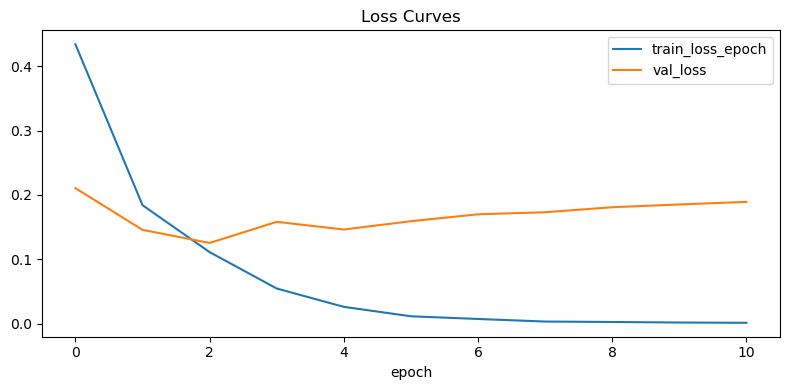

In [16]:
trainer.fit(mpnn, train_loader, test_loader)

# Plot after training
metrics = pd.read_csv(f"{logger.log_dir}/metrics.csv")

fig, ax = plt.subplots(figsize=(8, 4))
metrics[['epoch', 'train_loss_epoch']].dropna().plot(x='epoch', ax=ax, label='Train Loss')
metrics[['epoch', 'val_loss']].dropna().plot(x='epoch', ax=ax, label='Val Loss')
ax.set_title('Loss Curves')
plt.tight_layout()
plt.show()

In [17]:
from sklearn.metrics import balanced_accuracy_score
results = trainer.test(dataloaders=test_loader, weights_only=False)  # weights_only=False is only required with pytorch lightning version 2.6.0 or newer

# Get predictions for balanced accuracy
preds = trainer.predict(mpnn, test_loader)
preds = torch.concat(preds)
pred_labels = (preds > 0.5).int().numpy().flatten()
true_labels = [d.y[0] for d in test_data]
bal_acc = balanced_accuracy_score(true_labels, pred_labels)
print(f"Balanced Accuracy: {bal_acc:.4f}")



/opt/miniconda3/envs/GNN_chem2/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/checkpoint_connector.py:149: `.test(ckpt_path=None)` was called without a model. The best model of the previous `fit` call will be used. You can pass `.test(ckpt_path='best')` to use the best model or `.test(ckpt_path='last')` to use the last model. If you pass a value, this warning will be silenced.
Restoring states from the checkpoint path at /Users/viggo/Documents/AI4Mol/Project/GNN_chemprop/checkpoints/best-epoch=2-val_loss=0.13.ckpt
/opt/miniconda3/envs/GNN_chem2/lib/python3.11/site-packages/lightning/pytorch/core/saving.py:365: Skipping 'metrics' parameter because it is not possible to safely dump to YAML.
Loaded model weights from the checkpoint at /Users/viggo/Documents/AI4Mol/Project/GNN_chemprop/checkpoints/best-epoch=2-val_loss=0.13.ckpt


Output()

/opt/miniconda3/envs/GNN_chem2/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/opt/miniconda3/envs/GNN_chem2/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test/accuracy       │     0.95772784948349      │
│         test/roc          │    0.9892080426216125     │
└───────────────────────────┴───────────────────────────┘

Output()

/opt/miniconda3/envs/GNN_chem2/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Balanced Accuracy: 0.9492


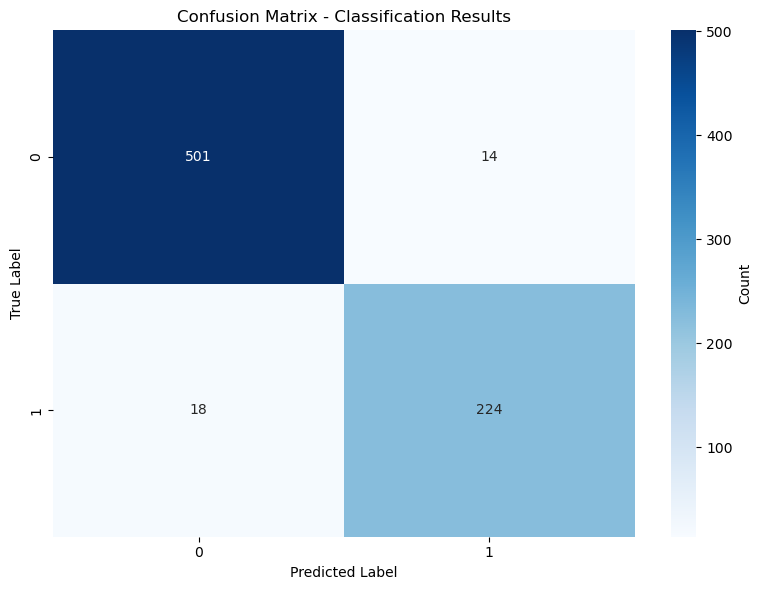

In [18]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(true_labels, pred_labels)

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar_kws={'label': 'Count'})
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix - Classification Results')
plt.tight_layout()
plt.show()